In [1]:
import argparse
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, EarlyStoppingCallback, BitsAndBytesConfig, pipeline
from datasets import load_dataset, Dataset
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import DataCollatorWithPadding
import evaluate
import numpy as np
from transformers import TrainerCallback
from torch.utils.data import DataLoader
from trl import SFTTrainer
from typing import Dict, Union, List, Any

# DEVICE = "cuda:1"
# MODEL_NAME="deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
MODEL_NAME="deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

/home/yash/.pyenv/versions/3.11.9/envs/FT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
from peft import get_peft_model, LoraConfig, TaskType
def load_model(model_id=MODEL_NAME, device= None, use_lora:bool=False):
    
    device = device if device else "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_id,
                                            trust_remote_code=True,
                                            padding_side = "right")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.add_eos_token
    
    model_load_kwargs = {
    "trust_remote_code": True,
    "device_map": device,
    "torch_dtype":torch.bfloat16,
}
    model = AutoModelForCausalLM.from_pretrained(model_id, **model_load_kwargs)
    # Apply LoRA if specified
    if use_lora:
        lora_config = LoraConfig(
            r=8,
            lora_alpha=32,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.CAUSAL_LM
        )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()
    
                                                
    return model, tokenizer



In [3]:
model,tokenizer = load_model(device="auto")
model.get_input_embeddings()

Embedding(151936, 1536)

In [4]:
tokenizer.model_max_length

16384

In [6]:
tokenizer

LlamaTokenizerFast(name_or_path='deepseek-ai/DeepSeek-R1-Distill-Qwen-7B', vocab_size=151643, model_max_length=16384, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<｜begin▁of▁sentence｜>', 'eos_token': '<｜end▁of▁sentence｜>', 'pad_token': '<｜end▁of▁sentence｜>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	151643: AddedToken("<｜end▁of▁sentence｜>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<｜User｜>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	151645: AddedToken("<｜Assistant｜>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	151646: AddedToken("<｜begin▁of▁sentence｜>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|EOT|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	151648: AddedToken("<think>", rstrip=False,

# Loading Dataset

In [3]:
dataset = load_dataset("mrSoul7766/ECTSum")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'summary'],
        num_rows: 1681
    })
    test: Dataset({
        features: ['text', 'summary'],
        num_rows: 495
    })
})

In [4]:
train_text_length = [len(i) for i in dataset["train"]["text"]]
train_summary_length = [len(i) for i in dataset["train"]["summary"]]
print(f"Min/Max/Mean Train Text Length : {min(train_text_length)}/{max(train_text_length)}/{np.mean(train_text_length):.2f}")
print(f"Min/Max/Mean Train Summary Length : {min(train_summary_length)}/{max(train_summary_length)}/{np.mean(train_summary_length):.2f}")


test_text_length = [len(i) for i in dataset["test"]["text"]]
test_summary_length = [len(i) for i in dataset["test"]["summary"]]
print(f"Min/Max/Mean Test Text Length : {min(test_text_length)}/{max(train_text_length)}/{np.mean(test_text_length):.2f}")
print(f"Min/Max/Mean Test Summary Length : {min(test_summary_length)}/{max(train_summary_length)}/{np.mean(test_summary_length):.2f}")

Min/Max/Mean Train Text Length : 1540/70127/17862.05
Min/Max/Mean Train Summary Length : 16/1675/274.35
Min/Max/Mean Test Text Length : 2776/70127/17584.18
Min/Max/Mean Test Summary Length : 22/1675/264.95


(array([ 96., 520., 634., 331.,  84.,  11.,   4.,   0.,   0.,   1.]),
 array([ 1583. ,  8449.7, 15316.4, 22183.1, 29049.8, 35916.5, 42783.2,
        49649.9, 56516.6, 63383.3, 70250. ]),
 <BarContainer object of 10 artists>)

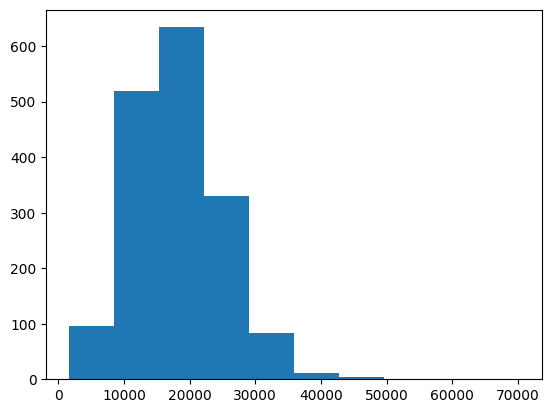

In [9]:
from matplotlib import pyplot as plt
total_seq = np.array(train_text_length) + np.array(train_summary_length)
plt.hist(total_seq)

## Preprocessing Dataset

In [4]:
# Improved system prompt with clearer instruction and output format
SYSTEM_PROMPT_FINANCIAL_SUMMARY = """You are a highly skilled financial analyst. Your task is to carefully analyze the provided financial document and generate a concise, structured summary. The summary should be in bullet points, with each point representing a key insight, trend, or significant financial detail. Ensure the summary is brief, accurate, and directly addresses the core financial information."""


DEFAULT_SYSTEM_PROMPT = """You are a financial expert. Read the financial document carefully and generate a concise bullet-point summary. Each bullet point should highlight a key insight or important detail. Keep the summary brief, clear, and to the point."""

# Instruction template for clarity
INSTRUCTION_TEMPLATE = "Analyze the following financial document and provide a bullet-point summary of the key findings:"


# very common
def create_prompt(text: str) -> str:
    """Create a prompt for instruction fine-tuning, incorporating a clearer structure."""
    return f"<instruction>{SYSTEM_PROMPT_FINANCIAL_SUMMARY}\n\n{INSTRUCTION_TEMPLATE}\n\n### Input: {text.strip()}\n\n### Response:\n- "
# Default system prompt for the financial summarization task

# model specific
def create_prompt_deepseek_qwen(text: str) -> str:
 
    return f"<｜begin of sentence｜><｜User｜>{DEFAULT_SYSTEM_PROMPT}\n\nSummarize the following financial document:\n{text.strip()}<｜Assistant｜>"

def preprocess_sample(data: Dict[str, Any], tokenizer, max_len=8192, is_train:bool=True ) -> Dict[str, Any]:
    """Preprocess a single data for model training."""
    try:
        # Extract text and summary based on data structure
        if isinstance(data.get("text"), dict):
            doc = data["text"].get("text", "")
            summary = data["text"].get("summary", "")
        else:
            # Try alternate format
            doc = data.get("text", "")
            summary = data.get("summary", "")
            
            # If still empty, try to use 'doc' directly
            if not doc:
                doc = data.get("doc", "")
        
        # Create the prompt format
        if is_train:
            prompt = create_prompt_deepseek_qwen(doc) + f"""\n### Response: {summary.strip()}"""
        else:
            prompt = create_prompt_deepseek_qwen(doc)
        
        # Tokenize the text with padding and truncation
        tokenized = tokenizer(
            prompt,
            max_length=max_len,
            truncation=True,
            
            return_tensors="pt",
        )
        
        # Remove the batch dimension that tokenizer adds when return_tensors="pt"
        tokenized = {k: v.squeeze(0) for k, v in tokenized.items()}
        
        # Store original text
        tokenized["combined_text"] = prompt
        
        # Prepare labels for causal language modeling
        # if is_train:
        tokenized["labels"] = tokenized["input_ids"].clone()
        # else:
        #     # For validation, we don't need labels for the input part
        #     # We can pad with -100 (the ignore index in PyTorch)
        #     input_len = prompt.rfind("### Response:") + len("### Response:")
        #     input_tokens = tokenizer(prompt[:input_len], max_length=max_len, truncation=True, return_tensors="pt")['input_ids'].squeeze(0)
        #     labels = [-100] * len(input_tokens)
        #     tokenized["labels"] = torch.tensor(labels)
        return tokenized
    
    except Exception as e:
        print(f"Error preprocessing example: {e}")
        # Return empty tensors with the right shape as fallback
        input_ids = torch.zeros(max_len, dtype=torch.long)
        attention_mask = torch.zeros(max_len, dtype=torch.long)
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": input_ids.clone(),
            "combined_text": ""
        }

In [5]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,  
    padding="longest",
    label_pad_token_id=-100,
)

In [6]:
split_dataset = dataset["train"].train_test_split(test_size=0.1,seed=42)
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]
test_dataset = dataset["test"]
print(f"train dataset size : {train_dataset.num_rows} \nval dataset size: {val_dataset.num_rows} \ntest dataset size : {test_dataset.num_rows}")

train dataset size : 1512 
val dataset size: 169 
test dataset size : 495


In [8]:
train_dataset, test_dataset

(Dataset({
     features: ['text', 'summary'],
     num_rows: 1512
 }),
 Dataset({
     features: ['text', 'summary'],
     num_rows: 495
 }))

In [10]:

sample1=preprocess_sample(train_dataset[999],tokenizer=tokenizer,max_len=8192)
sample1


{'input_ids': tensor([151646,     27, 130957,  ...,     17,     15,     13]),
 'attention_mask': tensor([1, 1, 1,  ..., 1, 1, 1]),
 'combined_text': "<｜begin of sentence｜><｜User｜>You are a financial expert. Read the financial document carefully and generate a concise bullet-point summary. Each bullet point should highlight a key insight or important detail. Keep the summary brief, clear, and to the point.\n\nSummarize the following financial document:\nThose and any other projections represent the current opinions of management, which are subject to change at any time, and we assume no obligation to update them.\nHe's done a great job representing the company to our investors and analysts and he will be sorely missed.\nYou have big shoes to fill and hope you are with us, at least 15 years like Brent.\nNow, this is the last panel I'll address you as Chief Executive Officer of Meritage Homes on an earnings call.\nAs we have previously announced, effective January 1, Phillippe Lord will t

In [11]:
sample1=preprocess_sample(val_dataset[100],tokenizer=tokenizer,max_len=1024,is_train=False)
sample1


{'input_ids': tensor([151646,     27, 130957,  ...,  23390,     11,  36749]),
 'attention_mask': tensor([1, 1, 1,  ..., 1, 1, 1]),
 'combined_text': "<｜begin of sentence｜><｜User｜>You are a financial expert. Read the financial document carefully and generate a concise bullet-point summary. Each bullet point should highlight a key insight or important detail. Keep the summary brief, clear, and to the point.\n\nSummarize the following financial document:\nJohn and David will provide high-level commentary regarding the quarter.\nWe appreciate you joining our call today.\nWe're very pleased with our fourth quarter and full-year results.\nWe achieved a great deal despite a challenging interest rate and operating environment.\nDespite continued economic uncertainty, we remain focused on what we can control, and our efforts are paying off.\nWe grew consumer checking accounts by 3% and small business accounts by 5%.\nNotably, our 2021 net retail account growth exceeds the previous three years c

In [12]:
print(f"\n\nInput Text: {sample1.get('combined_text')}")



Input Text: <｜begin of sentence｜><｜User｜>You are a financial expert. Read the financial document carefully and generate a concise bullet-point summary. Each bullet point should highlight a key insight or important detail. Keep the summary brief, clear, and to the point.

Summarize the following financial document:
John and David will provide high-level commentary regarding the quarter.
We appreciate you joining our call today.
We're very pleased with our fourth quarter and full-year results.
We achieved a great deal despite a challenging interest rate and operating environment.
Despite continued economic uncertainty, we remain focused on what we can control, and our efforts are paying off.
We grew consumer checking accounts by 3% and small business accounts by 5%.
Notably, our 2021 net retail account growth exceeds the previous three years combined and represents an annual growth rate that is three times higher than pre-pandemic levels.
We increased new corporate banking group loan p

## Data Tokenization

In [13]:
# train set
tokenized_train_dataset = train_dataset.map(lambda sample: preprocess_sample(sample,tokenizer,max_len=8192)).remove_columns(column_names=["text","summary"])

#val set
tokenized_val_dataset = val_dataset.map(lambda sample: preprocess_sample(sample,tokenizer,max_len=8192, is_train=False))


Map:  36%|███▌      | 544/1512 [00:04<00:07, 125.00 examples/s]

In [11]:
tokenized_train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'combined_text', 'labels'],
    num_rows: 1512
})

In [12]:
tokenized_val_dataset

Dataset({
    features: ['text', 'summary', 'input_ids', 'attention_mask', 'combined_text', 'labels'],
    num_rows: 169
})

# Testing: Zero shot Testing

In [11]:
import os
def load_best_model(output_dir):
    best_model_path = os.path.join(output_dir, "checkpoint-best")
    if not os.path.exists(best_model_path):
        # Fallback to a potentially differently named best checkpoint directory
        import glob
        best_checkpoint_dirs = glob.glob(os.path.join(output_dir, "checkpoint-*"))
        best_checkpoint_dirs.sort(key=lambda x: os.path.getmtime(x), reverse=True) # Sort by modification time, newest first
        for dirname in best_checkpoint_dirs:
            if "best" in dirname.lower():
                best_model_path = dirname
                break
        else:
            print(f"Warning: Could not find a 'checkpoint-best' directory. Loading the last saved model instead.")
            best_model_path = output_dir # Or adjust to your final saved model path

    try:
        tokenizer = AutoTokenizer.from_pretrained(best_model_path, trust_remote_code=True, padding_side="right")
        model = AutoModelForCausalLM.from_pretrained(best_model_path, trust_remote_code=True, device_map="auto")
        print(f"Successfully loaded the best model from: {best_model_path}")
        return model, tokenizer
    except Exception as e:
        print(f"Error loading best model from {best_model_path}: {e}")
        return None, None

# # to load the best model
output_dir = "/home/yash/Finetunning/ETCsum_finetuning/"


# model,tokenizer = load_best_model(output_dir)


In [9]:
# distill model
distill_model_name="deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

#base model:
base_model_name = "Qwen/Qwen2.5-1.5B"

#instruct_model_name
instruct_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
distill_model,distill_tokenizer = load_model(distill_model_name,device="cuda")
base_model,base_tokenizer = load_model(base_model_name,device="cuda")
instruct_model,instruct_tokenizer = load_model(instruct_model_name,device="cuda")


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [10]:
# from transformers import AutoConfig
# path = "/home/yash/Finetunning/finetuned_model"
# # config = AutoConfig.from_pretrained(path, trust_remote_code=True, local_files_only=True)
# new_model = AutoModelForCausalLM.from_pretrained(path, trust_remote_code=True, device_map= "auto",local_files_only=True, torch_dtype=torch.bfloat16)
# new_tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, padding_side="right")

In [10]:
# #task = text-generation, summarization
# m1 = pipeline("text-generation",model=model,tokenizer=tokenizer)
# m2 = pipeline("text-generation",model=new_model,tokenizer=new_tokenizer)

Device set to use cuda:0
Device set to use cuda:0


# Evaluation

In [10]:
import evaluate
from bert_score import score
rouge_metric = evaluate.load("rouge")
def generate_summary_with_metrics(model, tokenizer, test_dataset, max_length=8192, device="cuda:0"):
    """
    Generates summaries and calculates ROUGE and BERTScore.

    Args:
        model: The trained transformer model for generation.
        tokenizer: The tokenizer corresponding to the model.
        test_dataset: The Hugging Face Dataset with 'text' and 'summary' columns.
        max_length (int, optional): The maximum length of the generated summary. Defaults to 512.
        device (str, optional): The device to use for inference ('cuda' or 'cpu'). Defaults to 'cuda'.

    Returns:
        Dict: A dictionary containing the ROUGE and BERTScore metrics.
    """
    model.eval()  # Set the model to evaluation mode
    model.to(device)

    generated_summaries = []
    ground_truth_summaries = []

    for sample in test_dataset:
        input_text = sample["text"]
        summary = sample["summary"]
        ground_truth_summaries.append(summary)

        prompt = create_prompt_deepseek_qwen(input_text)
    
        generated_summary = summarize(model,tokenizer,prompt,device)
        generated_summaries.append(generated_summary)

    # Calculate ROUGE scores
    rouge_results = rouge_metric.compute(predictions=generated_summaries, references=ground_truth_summaries)
    rouge_results = {f"rouge_{key}": value * 100 for key, value in rouge_results.items()}

    # Calculate BERTScore
    P, R, F1 = score(generated_summaries, ground_truth_summaries, lang='en', verbose=False,device=device)
    bertscore_results = {
        "bertscore_precision": P.mean().item() * 100,
        "bertscore_recall": R.mean().item() * 100,
        "bertscore_f1": F1.mean().item() * 100,
    }

    metrics = {**rouge_results, **bertscore_results}
    # print("ROUGE Scores:", metrics)
    return metrics,generated_summaries

def summarize(model, tokenizer,text: str,device):
    text = create_prompt_deepseek_qwen(text)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.add_eos_token
    inputs = tokenizer(text, return_tensors="pt").to(device)
    inputs_length = len(inputs["input_ids"][0])
    with torch.inference_mode():
        outputs = model.generate(**inputs, max_new_tokens=256, temperature=0.0001)
    return tokenizer.decode(outputs[0][inputs_length:], skip_special_tokens=True)

In [11]:
doc = dataset["test"][0]["text"]
summary = dataset["test"][0]["summary"]

distill_model_response = summarize(distill_model,distill_tokenizer, doc,device="cuda:0")
print(distill_model_response)


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


<think>
Okay, so I need to summarize this financial document. Let me read through it carefully. It's about Aaron's Company, a financial institution. The document starts with a welcome message, then talks about their strong performance in the third quarter, continued growth, and positive momentum. They mention significant leadership improvements in the direct-to-consumer lease market and tracking well ahead of their strategic plan.

They also talk about investments in their best-in-class e-commerce channel, predictive lease decisioning engine, and GenNext stores. These are driving productivity and growth. They mention customer payment activity, which has been declining, and they expect it to normalize. They talk about e-commerce revenues increasing and their margins improving.

The document also covers their third-quarter results, which exceeded expectations, and their revenue and earnings outlook for the year. They mention capital expenditures and free cash flow, and their assumptions 

In [12]:
base_model_response = summarize(base_model,base_tokenizer, doc,device="cuda:0")
base_model_response

/home/yash/.pyenv/versions/3.11.9/envs/FT/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


'Thank you, Douglas.'

In [17]:
print(summary)

compname reports q3 non-gaap earnings per share $0.83.
q3 non-gaap earnings per share $0.83.
q3 revenue rose 2.5 percent to $452.2 million.
sees fy revenue $1.82 billion to $1.83 billion.
increased our expected 2021 adjusted ebitda to between $225 million and $230 million.
lowered our 2021 annual free cash flow outlook to between $30 million and $40 million.


In [10]:
instruct_model_response = summarize(instruct_model,instruct_tokenizer, doc,device="cuda:0")
print(instruct_model_response)

 Here’s a concise summary of the financial document:

* **Operating Performance**: Strong operating performance with continued positive momentum, especially in the direct-to-consumer lease end market.
* **Market Position**: Significant strengthening of leadership position in the direct-to-consumer lease end market since separation.
* **Investments**: Continued investments in best-in-class e-commerce channel, predictive lease decisioning engine, and GenNext stores.
* **Revenue Growth**: Third quarter 2021 results exceed expectations, returning $37.5 million to shareholders in share repurchases, bringing total capital returns to nearly $100 million so far this year.
* **Same-Store Revenue Growth**: Same-store revenues grew 4.6% compared to the previous year, led by a 8.7% larger lease portfolio size.
* **Customer Experience**: Enhanced shopping experience through personalized digital solutions, low monthly payments, and free delivery.
* **Earnings Outlook**: Raising revenue and earnings 

: 

In [13]:
import pprint
score,responses=generate_summary_with_metrics(instruct_model,instruct_tokenizer,dataset["test"].take(5),device="cuda:0")
pprint.pprint((score))


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'bertscore_f1': 81.43547177314758,
 'bertscore_precision': 78.52210402488708,
 'bertscore_recall': 84.61254835128784,
 'rouge_rouge1': np.float64(13.3245304136634),
 'rouge_rouge2': np.float64(3.465551372326628),
 'rouge_rougeL': np.float64(8.466500230161227),
 'rouge_rougeLsum': np.float64(13.62148093842225)}


In [18]:
score2,responses2=generate_summary_with_metrics(distill_model,distill_tokenizer,dataset["test"].take(5),device="cuda:0")
print()
pprint.pprint(score2)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
/pytorch/aten/src/ATen/native/cuda/TensorCompare.cu:110: _assert_async_cuda_kernel: block: [0,0,0], thread: [0,0,0] Assertion `probability tensor contains either `inf`, `nan` or element < 0` failed.


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [19]:
score3,responses3=generate_summary_with_metrics(distill_model,distill_tokenizer,dataset["test"].take(5),device="cuda:0")
print()
pprint.pprint(score2)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
